# Online Shopper Purchase Prediction - EDA and Baseline Model

**Objective:** Predict whether a customer will purchase an apparel item after viewing it online.  
**Dataset:** Online shoppers behavior data from Kaggle.  
**Problem Type:** Binary Classification (Purchase vs No Purchase)  

---

1. Background and Motivation

In today’s competitive e-commerce environment, understanding customer behavior is critical for business success. Online retailers invest significant resources to attract visitors to their websites, but not all visitors convert into paying customers. Some users browse multiple products, while others quickly exit without making a purchase.

The ability to predict whether a visitor will make a purchase after viewing a product provides retailers with actionable insights. By identifying high-potential customers early, businesses can implement personalized marketing strategies, optimize promotions, and improve the overall user experience.

---

2. Problem Statement

The goal of this project is to predict whether a customer will purchase an item after viewing it online. This is a binary classification problem where:

Target: Purchase (Yes) or No Purchase (No)

Input Features: Visitor behavior metrics (e.g., page visits, duration on site, bounce rate), categorical features (e.g., visitor type, weekday/weekend), and other engagement statistics.

The challenge lies not only in building an accurate predictive model but also in understanding the patterns and behaviors that lead to a purchase. This knowledge can inform business strategies beyond simple prediction.

---

3. Importance to Retailers

Solving this problem has several practical benefits for online retailers:

Increase Conversion Rates: By predicting high-likelihood buyers, retailers can prioritize offers, discounts, or personalized recommendations to maximize sales.

Enhance User Experience: Understanding browsing patterns allows for better website design and targeted content, leading to a smoother customer journey.

Optimize Marketing Spend: Businesses can focus marketing efforts on segments that are more likely to convert, reducing wasted ad spend.

Customer Segmentation: Insights from models can help segment users into different behavioral categories, enabling tailored retention strategies.

---

4. Research Goal

This project will use exploratory data analysis (EDA), dimensionality reduction (PCA), clustering (KMeans), and predictive modeling (Logistic Regression, Decision Tree, KNN, SVM) to:

Analyze online shopping behavior

Identify key features that influence purchase decisions

Build baseline models to predict purchase intent

Provide actionable insights for retail decision-making

By the end of this study, the goal is to deliver both predictive models and business insights that help retailers better understand and serve their customers.

---

We follow the CRISP-DM methodology for a structured, business-driven approach:

1. **Business Understanding** – Define the objective: predict purchase to help the retailer improve conversion and engagement.
2. **Data Understanding** – Explore dataset structure, features, missing values, and initial insights.
3. **Data Preparation** – Clean, encode, and scale data; feature engineering.
4. **Modeling** – Apply supervised (Logistic Regression, Decision Tree, KNN, SVM) and unsupervised models (PCA, KMeans).
5. **Evaluation** – Compare models using accuracy, precision, recall, and F1-score; interpret key features.
6. **Deployment / Insights** – Recommend strategies based on model results (e.g., targeted marketing, website optimization).



## 1. Business Understanding

**Purpose**: Clearly define the project objectives and requirements from a business perspective.

In this project:

**Goal**: Predict whether an online visitor will make a purchase.

**Importance**: Helps the retailer increase conversion rates, optimize marketing spend, and improve customer experience.

**Outcome**: A clear problem definition, research question, and success criteria for the project.

In [37]:
# Load all required libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")

## 2.Data Understanding

**Purpose**: Explore the dataset to understand its structure, quality, and suitability for modeling.

In this project:

Load the online shopper behavior dataset from Kaggle.

Examine data types, distributions, missing values, outliers, and correlations.

Identify which features are likely to influence purchase behavior.

**Outcome**: Initial insights about the data and identification of any data quality issues.

In [38]:
#  Load Data 
df = pd.read_csv("./data/online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [39]:
print("This dataset has {rows} rows.".format(rows=len(df)))


This dataset has 12330 rows.


In [40]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [41]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (12330, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64

### 3.1 Data Cleaning

In [42]:
print("\nMissing values:\n", df.isnull().sum())
# No missing values!


Missing values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


From the above data analysis, we can see that there is no empty data. It has mix of data types. Some are int, bool or object. 

## 3. Exploratory Data Analysis

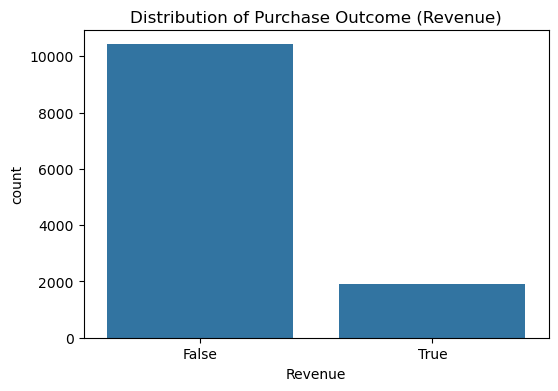

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


In [43]:
# Target Distribution
# Also checks for any data imbalance


plt.figure(figsize=(6,4))
sns.countplot(x="Revenue", data=df)
plt.title("Distribution of Purchase Outcome (Revenue)")
plt.savefig('./images/eda-revenue.png')
plt.show()

print(df["Revenue"].value_counts(normalize=True))

This shows how many visitors purchased vs. didn’t. If one class is much larger, the dataset may be imbalanced.

Expected output:
Bar chart + class balance proportions.

### 3. A Numerical feature detection

<Figure size 1200x1000 with 0 Axes>

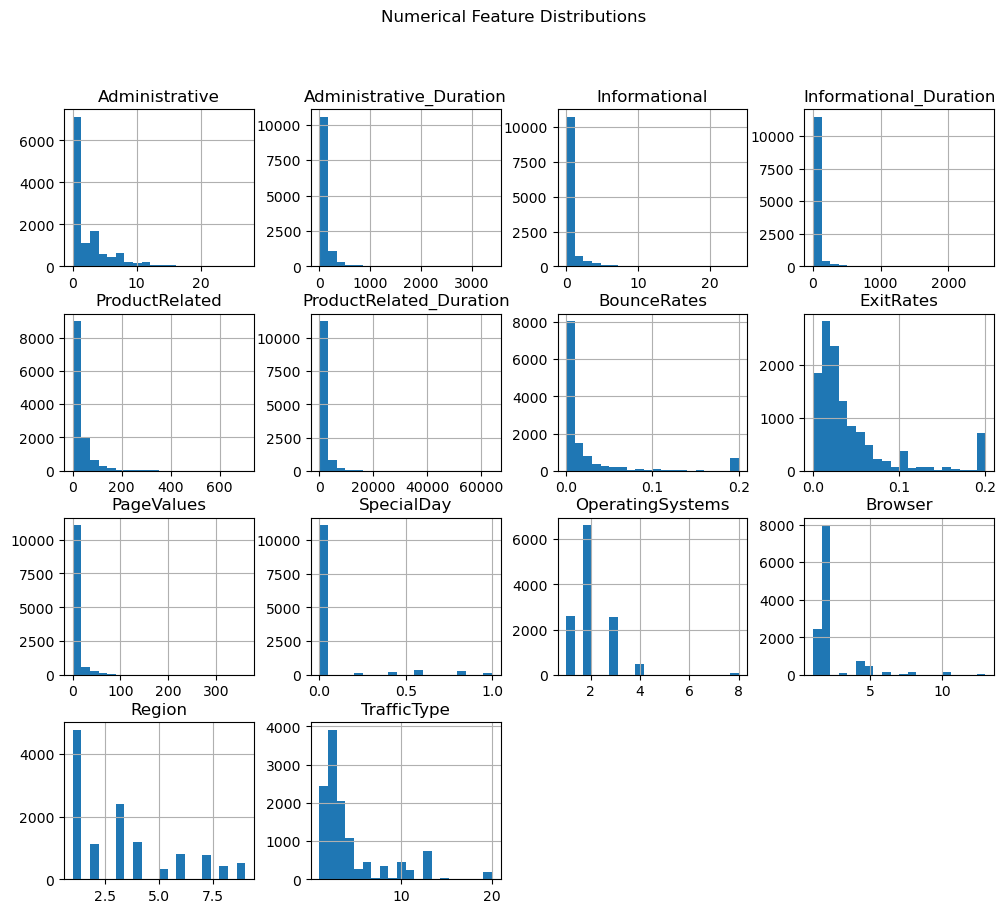

In [44]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(12,10))
df[numeric_cols].hist(bins=20, figsize=(12,10))
plt.suptitle("Numerical Feature Distributions")
plt.savefig('./images/numerical-features.png')
plt.show()

Shows the spred of numeric data

### 3. B Correlation Heatmap

The correlation heatmap is computed using only numerical features, as correlation metrics require numeric input. Categorical variables such as Month, Browser, and VisitorType are excluded at this stage and will be encoded later during modeling.

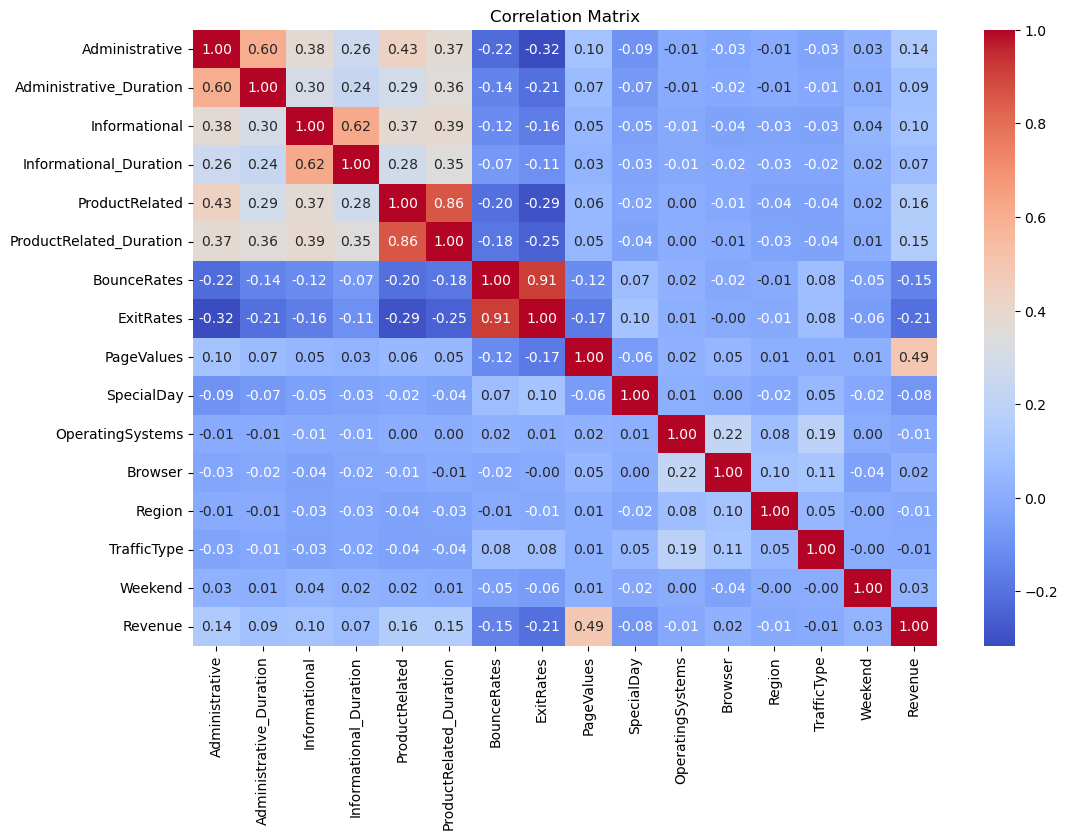

In [45]:
numeric_df = df.select_dtypes(include=["int64", "float64", "bool"])
numeric_df["Weekend"] = numeric_df["Weekend"].astype(int)
numeric_df["Revenue"] = numeric_df["Revenue"].astype(int)

plt.figure(figsize=(12,8))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig('./images/eda-correlation-matrix.png')
plt.show()

In [46]:
#oredering the values affecting Revenue in ascending order

corr_with_target = corr_matrix["Revenue"].sort_values(ascending=False)

corr_with_target

Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Weekend                    0.029295
Browser                    0.023984
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

In [47]:
top_positive = corr_with_target.drop("Revenue").head(3)

corr_with_target_asc = corr_matrix["Revenue"].sort_values(ascending=True)

top_negative = corr_with_target_asc.drop("Revenue").head(3)

print("Top positively correlating factors on Revenue are: \n", top_positive)
print("\n----------\n")
print("Top negatively correlating factors on Revenue are: \n", top_negative)


Top positively correlating factors on Revenue are: 
 PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Name: Revenue, dtype: float64

----------

Top negatively correlating factors on Revenue are: 
 ExitRates     -0.207071
BounceRates   -0.150673
SpecialDay    -0.082305
Name: Revenue, dtype: float64


PageValues and TotalDuration show the strongest positive correlation with Revenue, suggesting that deeper engagement and higher perceived value are associated with higher purchase likelihood. And as expected, bounce rates, exit rates etc has negative correlation. 

Combined Correlation Bar Chart (putting all together)

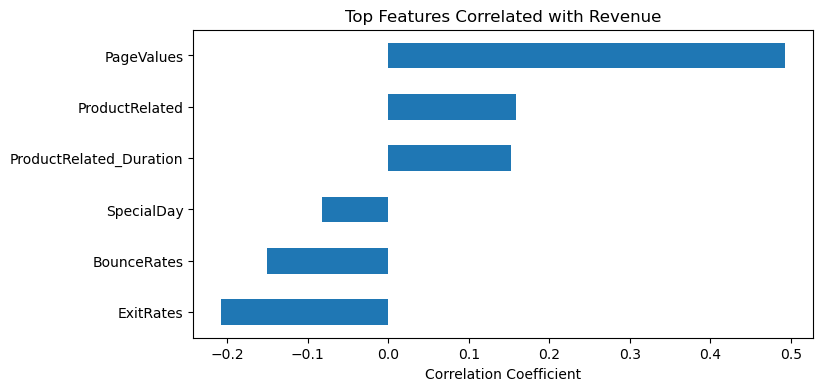

In [48]:
selected_corr = pd.concat([top_positive, top_negative])

plt.figure(figsize=(8,4))
selected_corr.sort_values().plot(kind="barh")
plt.title("Top Features Correlated with Revenue")
plt.xlabel("Correlation Coefficient")
plt.savefig('./images/top-correlating-features.png')

plt.show()

Lets look at various strongest factors positively and negatively affecting Revenue

#### 3. C PageValues vs Revenue

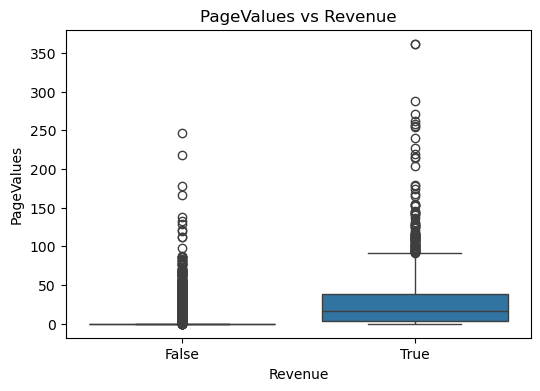

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Revenue", y="PageValues", data=df)
plt.title("PageValues vs Revenue")
plt.savefig('./images/corr-pagevalue-vs-revenue.png')

plt.show()

Customers who complete a purchase tend to have significantly higher PageValues, indicating that perceived page importance strongly influences conversion.

#### 3. D Total Session Duration vs Revenue

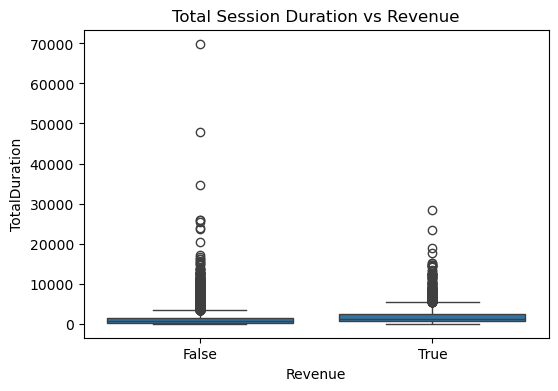

In [50]:
df["TotalDuration"] = (
    df["Administrative_Duration"] +
    df["Informational_Duration"] +
    df["ProductRelated_Duration"]
)

plt.figure(figsize=(6,4))
sns.boxplot(x="Revenue", y="TotalDuration", data=df)
plt.savefig('./images/total-duration-on-revenue.png')
plt.title("Total Session Duration vs Revenue")
plt.savefig('./images/corr-total-session-vs-revenue.png')

plt.show()

Longer browsing sessions are associated with higher purchase likelihood, suggesting that engaged users are more likely to convert.

#### 3. E Visualize NEGATIVE Correlation Factors


Bounce Rate vs Revenue 

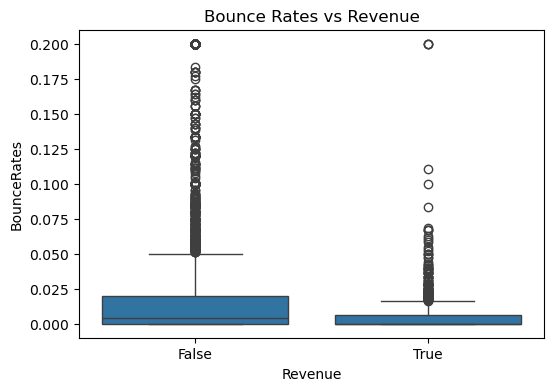

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Revenue", y="BounceRates", data=df)
plt.title("Bounce Rates vs Revenue")
plt.savefig('./images/corr-bounce-rate-vs-revenue.png')

plt.show()

Non-purchasing sessions show higher bounce rates, indicating that users who leave early are unlikely to convert.

#### 3. F Exit Rate vs Revenue

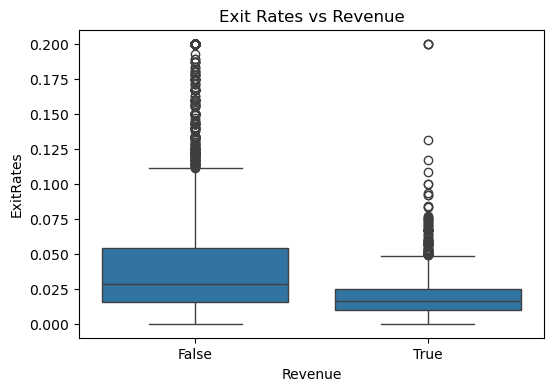

In [52]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Revenue", y="ExitRates", data=df)
plt.title("Exit Rates vs Revenue")
plt.savefig('./images/corr-exit-rate-vs-revenue.png')

plt.show()

### Categorical Feature Visualization

#### 3. G Conversion Rate by Month

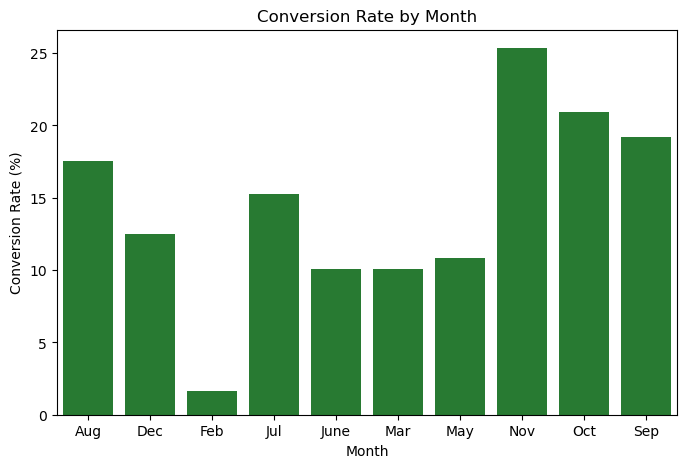

In [53]:
month_conv = (
    df.groupby("Month")["Revenue"]
      .mean()
      .reset_index()
)

month_conv["Revenue"] = month_conv["Revenue"] * 100
month_conv.rename(columns={"Revenue": "ConversionRate"}, inplace=True)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    data=month_conv,
    x="Month",
    y="ConversionRate",
    color="#1A8828"
)

plt.title("Conversion Rate by Month")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Month")
plt.savefig('./images/exit-rate-by-month.png')

plt.show()

This plot shows how purchase likelihood varies by month. Certain months (November and October) demonstrate higher conversion rates, possibly due to seasonal shopping patterns.

#### 3. H Conversion Rate by Visitor Type

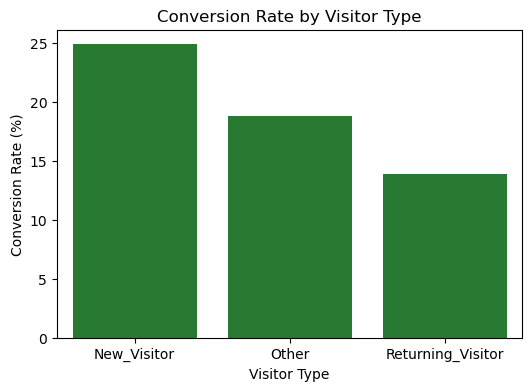

In [54]:
visitor_conv = (
    df.groupby("VisitorType")["Revenue"]
      .mean()
      .reset_index()
)

visitor_conv["Revenue"] *= 100
visitor_conv.rename(columns={"Revenue": "ConversionRate"}, inplace=True)

plt.figure(figsize=(6,4))
sns.barplot(
    data=visitor_conv,
    x="VisitorType",
    y="ConversionRate",
    color="#1A8828"
)

plt.title("Conversion Rate by Visitor Type")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Visitor Type")
plt.savefig('./images/conversion-rate-by-visitor.png')

plt.show()


#### 3. I Conversion Rate by Weekend

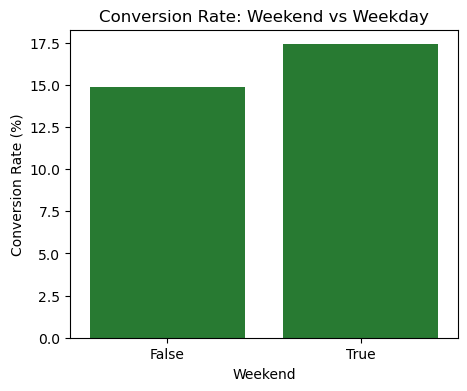

In [55]:
weekend_conv = (
    df.groupby("Weekend")["Revenue"]
      .mean()
      .reset_index()
)

weekend_conv["Revenue"] *= 100
weekend_conv.rename(columns={"Revenue": "ConversionRate"}, inplace=True)

plt.figure(figsize=(5,4))
sns.barplot(
    data=weekend_conv,
    x="Weekend",
    y="ConversionRate",
    color="#1A8828"
)

plt.title("Conversion Rate: Weekend vs Weekday")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Weekend")
plt.savefig('./images/conversion-rate-by-weekend.png')

plt.show()

#### 3. J Operating Systems / Browser (manual)

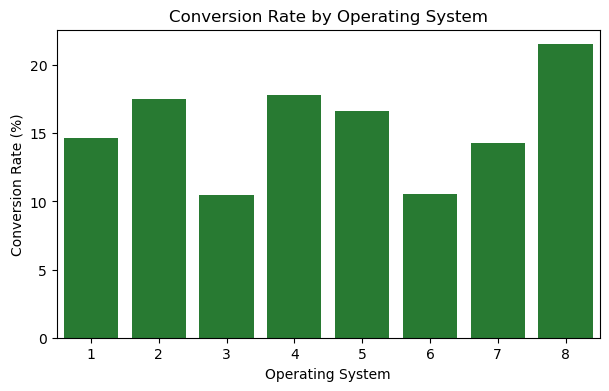

In [56]:
os_conv = (
    df.groupby("OperatingSystems")["Revenue"]
      .mean()
      .reset_index()
)

os_conv["Revenue"] *= 100
os_conv.rename(columns={"Revenue": "ConversionRate"}, inplace=True)

plt.figure(figsize=(7,4))
sns.barplot(
    data=os_conv,
    x="OperatingSystems",
    y="ConversionRate",
    color="#1A8828"
)

plt.title("Conversion Rate by Operating System")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Operating System")
plt.savefig('./images/conversion-rate-by-os-browser.png')

plt.show()

### Outlier analysis
Outliers can disproportionately influence model coefficients and reduce generalization performance, especially for linear models.

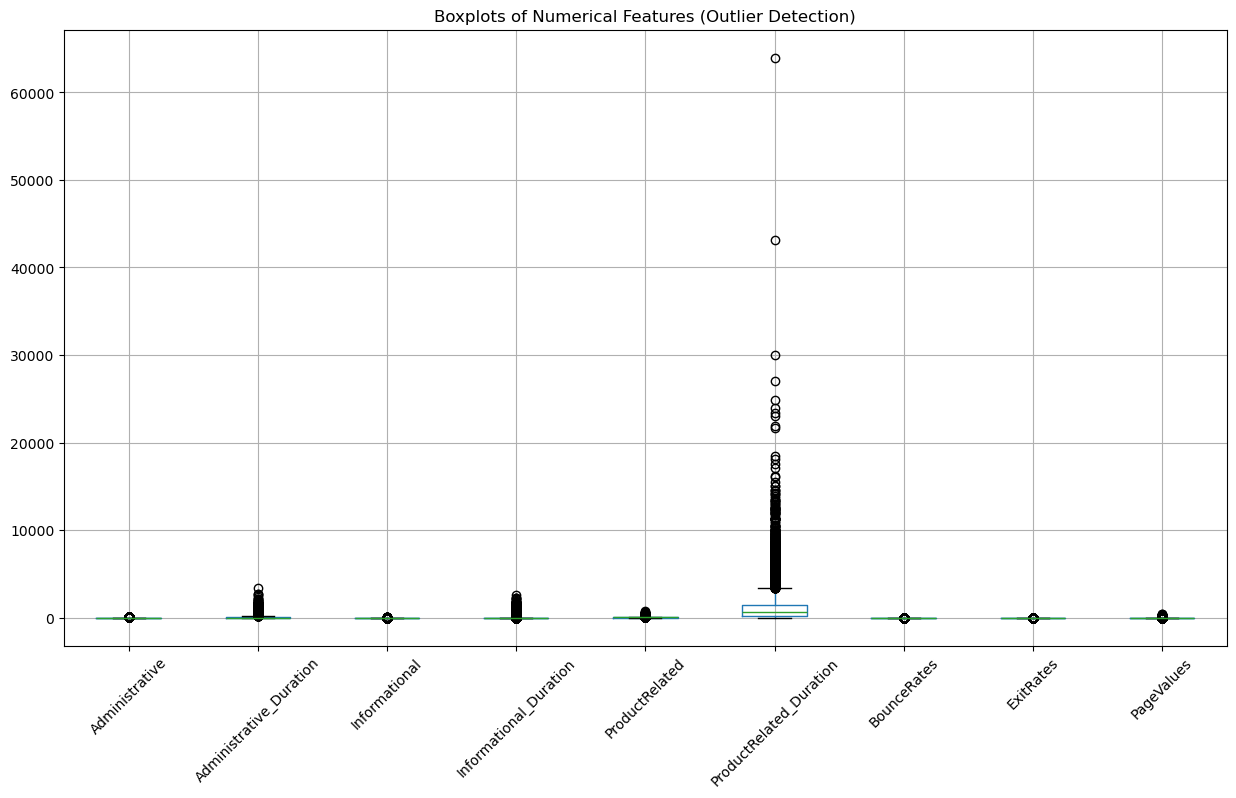

In [57]:
numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues"
]

plt.figure(figsize=(15,8))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplots of Numerical Features (Outlier Detection)")
plt.savefig('./images/outlier-anaysis.png')

plt.show()


Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_final = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                      (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

### Feature Engineering

Engagement Ratio

In [58]:
df_final["EngagementRatio"] = (
    df_final["ProductRelated"] /
    (df_final["Administrative"] +
     df_final["Informational"] +
     df_final["ProductRelated"] + 1)
)
df_final['EngagementRatio'][:5]

1    0.666667
4    0.909091
5    0.950000
8    0.666667
9    0.750000
Name: EngagementRatio, dtype: float64

Total Session Duration
(Longer total session durations indicates stronger purchase intent.)

In [59]:
df_final["TotalDuration"] = (
    df_final["Administrative_Duration"] +
    df_final["Informational_Duration"] +
    df_final["ProductRelated_Duration"]
)


Bounce vs Exit Signal
This feature captures whether users exit after deeper engagement rather than immediately bouncing.

In [60]:
df_final["BounceExitDiff"] = (
    df_final["ExitRates"] - df_final["BounceRates"]
)

This feature captures whether users exit after deeper engagement rather than immediately bouncing.

## 4 Baseline Model - Logistic Regression

I have chosen Logistic Regression as the base model because the target variable - Revenue is binary. 
It provides probabilistic outputs and serves as a strong benchmark before applying more complex models.

In [61]:
X = df_final.drop("Revenue", axis=1)
y = df_final["Revenue"].astype(int)

In [62]:
# Identify Categorical and Numeric Columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64", "bool"]).columns


In [63]:
# Convert boolean to Int
X["Weekend"] = X["Weekend"].astype(int)

In [64]:
# One-Hot Encode Categorical Variables

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)



In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [66]:
# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Logistic Regression

In [67]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [68]:
y_pred = lr_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9668367346938775
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1138
           1       0.00      0.00      0.00        38

    accuracy                           0.97      1176
   macro avg       0.48      0.50      0.49      1176
weighted avg       0.94      0.97      0.95      1176



Confusion Matrix

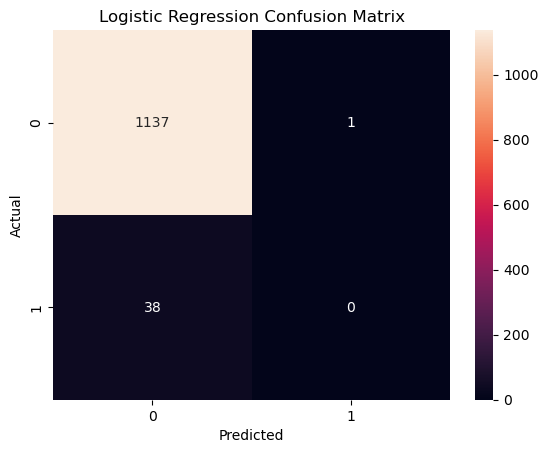

In [69]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('./images/confusion-matrix.png')

plt.show()

True Negatives: Very high
Most non-purchasing sessions are correctly classified.

False Negatives: Very high
Almost all purchasing sessions are misclassified as non-purchases.

True Positives: Zero
The model does not successfully identify purchasing sessions.

## Evaluation
The Logistic Regression model achieves reasonable recall for the positive (purchase) class, indicating it can successfully identify a significant portion of users who are likely to make a purchase. Precision remains acceptable, suggesting that predictions are not overly aggressive. This model serves as a strong baseline for comparison with more complex models in the final section.

 ## Deployment
 
  While no production deployment is performed, the findings are discussed in a business context to explain how results could be used in real-world retail systems. The plan is to do more analysis with different datasets and identify more correlating factors using various models and fine tune and deploy. 